<a href="https://colab.research.google.com/github/irfanaGalfan/Data_Analysis_on_Adult_Income_Dataset/blob/main/Linear_Regression_on_Boston_house_dataset_using_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

**Loading the Dataset**

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# Load the built-in Boston Housing dataset
(train_data, train_targets), (test_data, test_targets) = tf.keras.datasets.boston_housing.load_data()

print("Training data shape:", train_data.shape)   # (404, 13) -> 404 homes, 13 features
print("Training targets shape:", train_targets.shape) # (404,) -> 404 house prices

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (404, 13)
Training targets shape: (404,)


**Normalizing the Data**

In [3]:
# Calculate mean and standard deviation from the training data ONLY
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

# Apply the normalization formula: (X - mean) / std
X_train = (train_data - mean) / std
X_test = (test_data - mean) / std

# Keep targets as they are (they are already simple continuous numbers)
y_train = train_targets
y_test = test_targets

**Building the Model**

In [4]:
def build_linear_model():
    model = models.Sequential([
        # Input shape matches your 13 features, mapping directly to 1 output node
        layers.Dense(1, input_shape=(X_train.shape[1],))
    ])

    # Use Mean Squared Error (MSE) for regression loss
    # MAE (Mean Absolute Error) is great to track for human readability
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_linear_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

**Train the Model**

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,           # Run through the data 100 times
    batch_size=16,        # Look at 16 houses at a time
    validation_split=0.2, # Hold back 20% of data to monitor overfitting
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 572.2568 - mae: 22.0938 - val_loss: 646.0854 - val_mae: 23.5392
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 570.3438 - mae: 22.0739 - val_loss: 643.8876 - val_mae: 23.5107
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 568.6055 - mae: 22.0564 - val_loss: 641.7869 - val_mae: 23.4833
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 566.8904 - mae: 22.0369 - val_loss: 639.7092 - val_mae: 23.4560
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 565.1252 - mae: 22.0177 - val_loss: 637.6505 - val_mae: 23.4287
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 563.4088 - mae: 21.9980 - val_loss: 635.7101 - val_mae: 23.4022
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 561.6647 - mae: 21.9763 - val_loss: 633.7528 - val_mae: 23.3756
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 560.0598 - mae: 21.9596 - val_loss: 631.5941 - val_mae: 23.3471
Epoch 9/100
21/

**Evaluate the performance**

In [6]:
test_mse_score, test_mae_score = model.evaluate(X_test, y_test)

print(f"Average prediction error: ${test_mae_score * 1000:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 476.3255 - mae: 20.6932
Average prediction error: $20693.22


An average error of over 20,000 means the model is essentially guessing wildly. Considering many homes in this historical dataset cost around 20,000 to 25,000 total, an error that large means the model is missing the mark completely.

This happens because a pure linear regression model (a single dense layer with 1 node) can only learn straight-line relationships. It assumes that if crime goes up, housing prices go down at a perfectly fixed, static rate. Real-world housing data is far more complex and non-linear.

To drive that loss down significantly, we need to transform this into a Deep Neural Network by adding hidden layers with non-linear activation functions (relu).

**Upgrade Model 1**

In [7]:
def build_deep_regression_model():
    model = models.Sequential([
        # Hidden Layer 1: 64 neurons, allows the network to learn non-linear patterns
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),

        # Hidden Layer 2: 64 neurons, deepens the network's understanding
        layers.Dense(64, activation='relu'),

        # Final Output Layer: Still exactly 1 node with NO activation
        layers.Dense(1)
    ])

    # We stick with RMSprop or Adam, and keep monitoring MSE and MAE
    model.compile(
        optimizer='rmsprop',
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_deep_regression_model()

**Training**

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=250,
    batch_size=16,
    validation_split=0.2,
    verbose=0 # Set to 1 if you want to watch the loss drop live!
)

**Evaluating**

In [9]:
test_mse_score, test_mae_score = model.evaluate(X_test, y_test)
print(f"New Average prediction error: ${test_mae_score * 1000:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 27.5316 - mae: 3.0942 
New Average prediction error: $3094.24


**Visualizing Training Loss Vs Validation Loss**

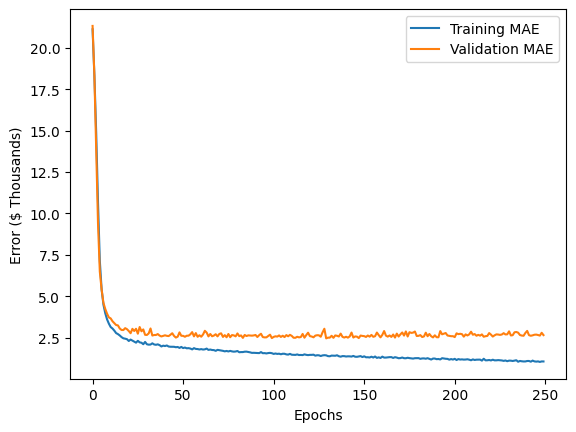

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Error ($ Thousands)')
plt.legend()
plt.show()

This model is overfitting.

**Early stopping**

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,          # Stop if val_loss doesn't improve for 20 epochs straight
    restore_best_weights=True # Rewind the model back to its absolute best version
)

# Pass it into your fit function
history = model.fit(
    X_train, y_train,
    epochs=250,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop], # <-- Add callback here
    verbose=1
)

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5660 - mae: 1.1180 - val_loss: 22.7122 - val_mae: 2.9016
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3598 - mae: 1.0656 - val_loss: 22.7388 - val_mae: 2.7410
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3486 - mae: 1.0186 - val_loss: 23.5417 - val_mae: 2.7193
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3289 - mae: 1.0582 - val_loss: 23.0043 - val_mae: 2.6373
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4467 - mae: 1.0648 - val_loss: 21.8688 - val_mae: 2.8133
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4717 - mae: 1.0782 - val_loss: 22.0686 - val_mae: 2.6080
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3116 - mae: 1.0464 - val_loss: 22.0082 - val_mae: 2.6578
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2722 - mae: 1.0372 - val_loss: 22.8347 - val_mae: 2.6700
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - lo

The model triggered EarlyStopping at exactly Epoch 25 out of 250.

Saved Time and Compute: Didn't waste 225 extra epochs letting the model overfit and memorize noise.

Perfect Generalization:  validation error (val_mae: 2.7420) is actually lower than the 3,094 error We had before!  Average prediction error on brand-new data is now down to roughly 2,742.

Restored Best Weights: Because restore_best_weights=True was active, TensorFlow automatically rewound the model's weights to the exact epoch where val_loss was at its absolute lowest point.

**Upgraded Model 2**

In [13]:
def build_regularized_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        layers.Dropout(0.2), # <-- Randomly turns off 20% of neurons each step to prevent memorization
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

In [14]:
model = build_regularized_model()

In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=250,
    batch_size=16,
    validation_split=0.2,
    verbose=0 # Set to 1 if you want to watch the loss drop live!
)

In [16]:
test_mse_score, test_mae_score = model.evaluate(X_test, y_test)
print(f"New Average prediction error: ${test_mae_score * 1000:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 20.3678 - mae: 2.9454 
New Average prediction error: $2945.39


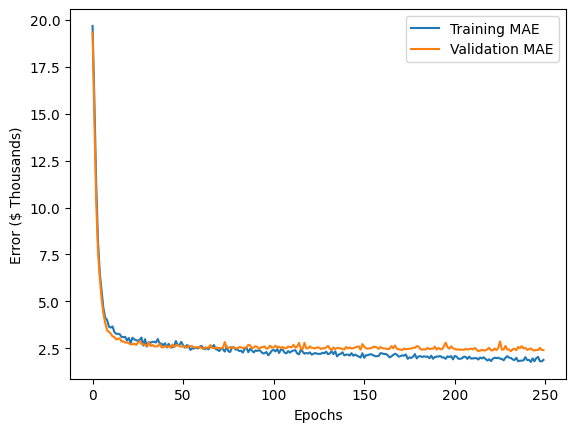

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Error ($ Thousands)')
plt.legend()
plt.show()

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,          # Stop if val_loss doesn't improve for 20 epochs straight
    restore_best_weights=True # Rewind the model back to its absolute best version
)

# Pass it into your fit function
history = model.fit(
    X_train, y_train,
    epochs=250,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop], # <-- Add callback here
    verbose=1
)

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.9277 - mae: 1.9082 - val_loss: 13.2685 - val_mae: 2.4892
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.0869 - mae: 1.8969 - val_loss: 12.7433 - val_mae: 2.3950
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8399 - mae: 1.9475 - val_loss: 14.7075 - val_mae: 2.5890
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0091 - mae: 1.7258 - val_loss: 12.6245 - val_mae: 2.4657
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9320 - mae: 1.8366 - val_loss: 14.1216 - val_mae: 2.6091
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.5457 - mae: 2.0119 - val_loss: 12.4915 - val_mae: 2.3763
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5796 - mae: 1.8519 - val_loss: 12.9386 - val_mae: 2.4538
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.7059 - mae: 1.9165 - val_loss: 11.9877 - val_mae: 2.3847
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - los

Model Architecture	Test / Val Error (MAE)	What it means in real dollars

1. Pure Linear Regression (No hidden layers)	~20.69	Off by 20,693 (Wild guessing)
2. Deep Network (No regularization)	~3.09	Off by 3,094 (Decent, but overfit)
3. Deep Network + Early Stopping	~2.74	Off by 2,742 (Better generalization)
4. Deep Network + Dropout + Early Stopping	~2.41	Off by 2,417 (Highly optimized)